# Bank Churn Modelling - TensorFlow Classification Model

This notebook builds a TensorFlow / Keras neural network to predict customer churn (**Exited**) from the **Churn_Modelling.csv** dataset.

**Steps:**
1. Load & explore the data (EDA)
2. Clean & preprocess (drop identifiers, encode categoricals, scale numerics)
3. Hyperparameter tuning (grid search with early stopping)
4. Train the best model and evaluate on a held-out test set (accuracy, precision, recall, F1, AUC)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve,
)

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")
print("TensorFlow version:", tf.__version__)

C:\Users\yasrm\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


TensorFlow version: 2.21.0


In [2]:
df = pd.read_csv("Churn_Modelling.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Drop identifiers that carry no predictive information
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

print("\n--- Missing values ---")
print(df.isnull().sum().sum(), "missing values total")
print("\n--- Target distribution ---")
print(df["Exited"].value_counts())


--- Missing values ---
0 missing values total

--- Target distribution ---
Exited
0    7963
1    2037
Name: count, dtype: int64


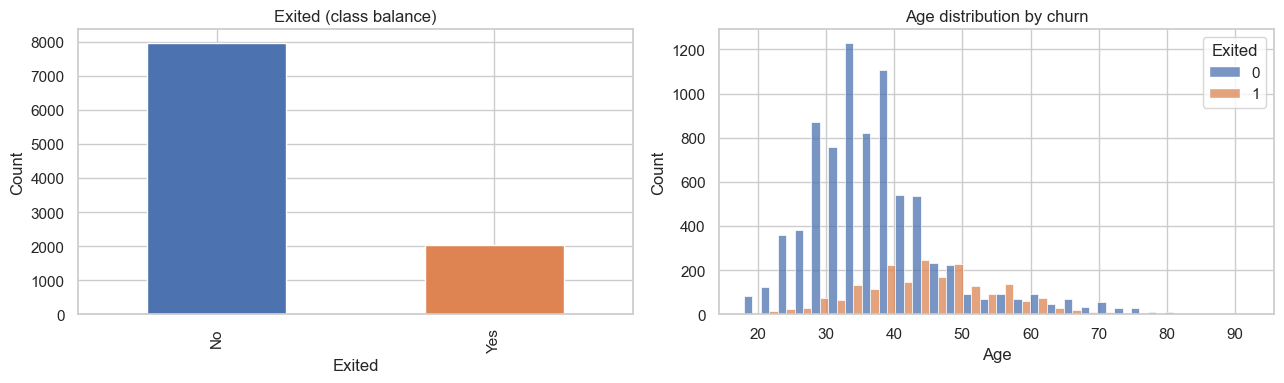

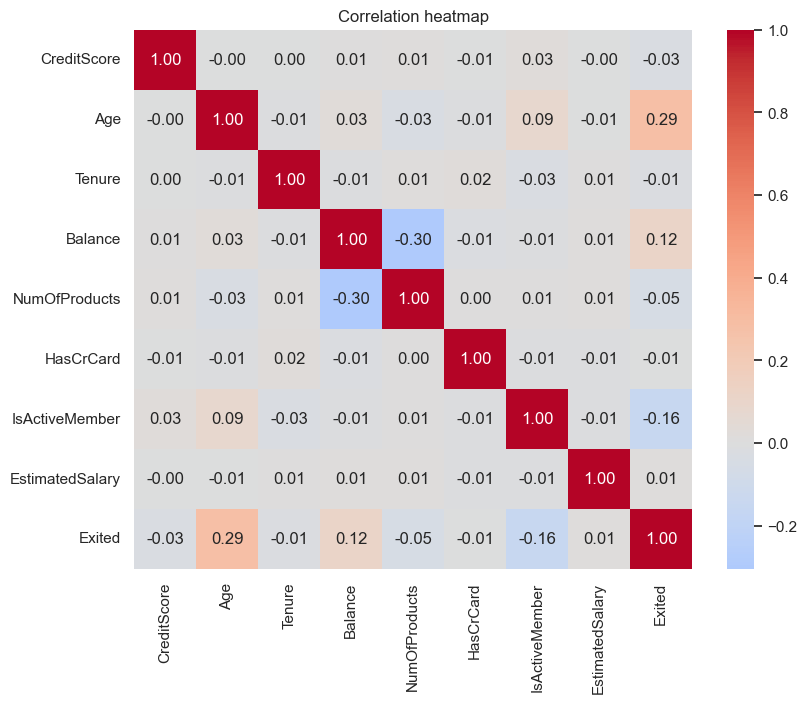

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["Exited"].map({0: "No", 1: "Yes"}).value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Exited (class balance)")
axes[0].set_ylabel("Count")

sns.histplot(data=df, x="Age", hue="Exited", bins=30, ax=axes[1], multiple="dodge")
axes[1].set_title("Age distribution by churn")
plt.tight_layout()
plt.show()

corr = df.select_dtypes("number").corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

In [5]:
# One-hot encode categorical features
df_enc = pd.get_dummies(df, columns=["Geography", "Gender"], dtype=np.float32)

y = df_enc["Exited"].to_numpy().astype(np.float32)
X = df_enc.drop(columns=["Exited"]).astype(np.float32).to_numpy()
print("Feature matrix:", X.shape)

# Stratified split keeps class balance in every set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Feature matrix: (10000, 13)
Train: (6400, 13) | Val: (1600, 13) | Test: (2000, 13)


In [6]:
def build_model(input_dim, hidden_layers=2, units=64, dropout=0.0, lr=1e-3):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))
    for _ in range(hidden_layers):
        model.add(tf.keras.layers.Dense(units, activation="relu"))
        if dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

def train_model(params, X_tr, y_tr, X_va, y_va, epochs=100, patience=10):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    model = build_model(X_tr.shape[1], **{k: v for k, v in params.items() if k != "batch_size"})
    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True
    )
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        batch_size=params.get("batch_size", 32),
        callbacks=[es],
        verbose=0,
    )
    val_loss = min(hist.history["val_loss"])
    return model, hist, val_loss

In [7]:
# --- Hyperparameter grid search ---
param_grid = [
    {"hidden_layers": 2, "units": 64,  "dropout": 0.0, "lr": 1e-3, "batch_size": 32},
    {"hidden_layers": 2, "units": 128, "dropout": 0.2, "lr": 1e-3, "batch_size": 32},
    {"hidden_layers": 3, "units": 64,  "dropout": 0.1, "lr": 1e-3, "batch_size": 64},
    {"hidden_layers": 3, "units": 128, "dropout": 0.3, "lr": 5e-4, "batch_size": 64},
    {"hidden_layers": 4, "units": 128, "dropout": 0.3, "lr": 5e-4, "batch_size": 64},
]

results = []
for i, p in enumerate(param_grid):
    model, hist, val_loss = train_model(p, X_train, y_train, X_val, y_val)
    results.append((val_loss, p))
    print(f"[{i+1}/{len(param_grid)}] {p} -> val_loss(BCE) = {val_loss:.4f}")

best_val_loss, best_params = min(results, key=lambda t: t[0])
print("\n=== BEST PARAMS (lowest val loss) ===")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"  val BCE = {best_val_loss:.4f}")

[1/5] {'hidden_layers': 2, 'units': 64, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32} -> val_loss(BCE) = 0.3501


[2/5] {'hidden_layers': 2, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32} -> val_loss(BCE) = 0.3484


[3/5] {'hidden_layers': 3, 'units': 64, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 64} -> val_loss(BCE) = 0.3489


[4/5] {'hidden_layers': 3, 'units': 128, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 64} -> val_loss(BCE) = 0.3498


[5/5] {'hidden_layers': 4, 'units': 128, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 64} -> val_loss(BCE) = 0.3461

=== BEST PARAMS (lowest val loss) ===
  hidden_layers: 4
  units: 128
  dropout: 0.3
  lr: 0.0005
  batch_size: 64
  val BCE = 0.3461


In [8]:
# --- Final model trained on train+val, evaluated on test ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)

X_final = np.vstack([X_train, X_val])
y_final = np.concatenate([y_train, y_val])

model = build_model(X_final.shape[1], **{k: v for k, v in best_params.items() if k != "batch_size"})
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
hist = model.fit(
    X_final, y_final,
    epochs=150,
    batch_size=best_params["batch_size"],
    validation_split=0.15,
    callbacks=[es],
    verbose=0,
)

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy  = {acc:.4f}")
print(f"Test Precision = {prec:.4f}")
print(f"Test Recall    = {rec:.4f}")
print(f"Test F1 Score  = {f1:.4f}")
print(f"Test AUC       = {auc:.4f}")

Test Accuracy  = 0.8660
Test Precision = 0.7725
Test Recall    = 0.4840
Test F1 Score  = 0.5952
Test AUC       = 0.8564


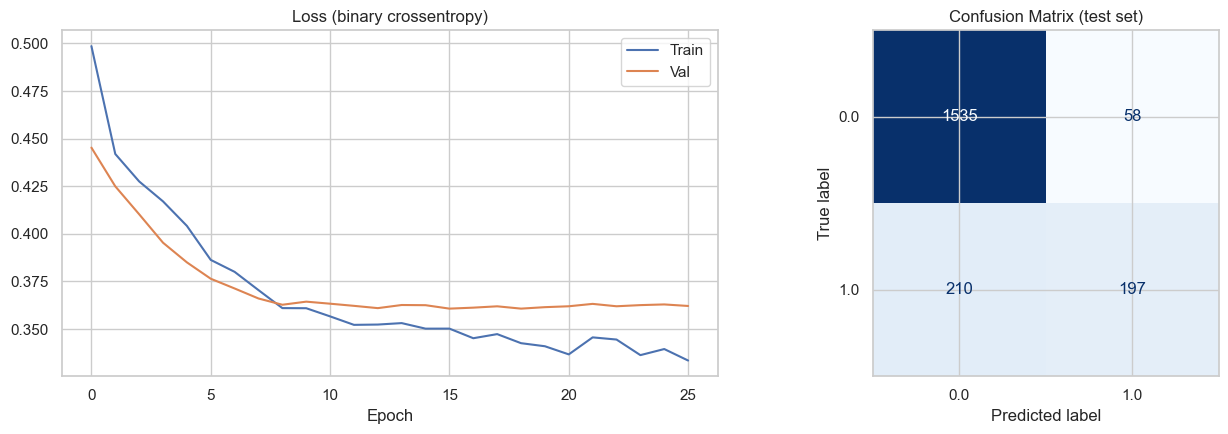

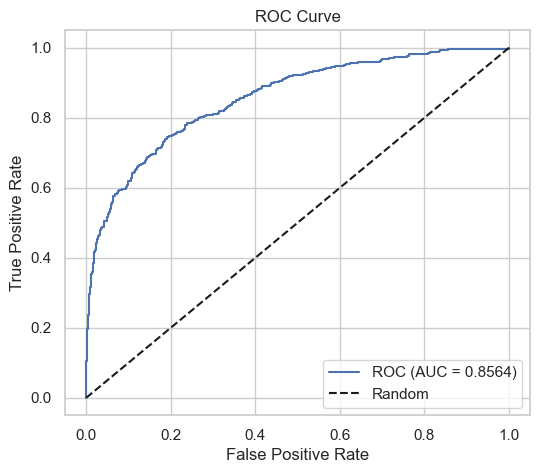

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(hist.history["loss"], label="Train")
axes[0].plot(hist.history["val_loss"], label="Val")
axes[0].set_title("Loss (binary crossentropy)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Confusion Matrix (test set)")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [10]:
print("## Summary")
print("")
print("- **Best hyperparameters:** " + ", ".join(f"{k}={v}" for k, v in best_params.items()))
print("- **Final test performance:** Accuracy = %.4f, Precision = %.4f, Recall = %.4f, F1 = %.4f, AUC = %.4f" % (acc, prec, rec, f1, auc))
print("")
print("The model correctly identifies churners with an AUC of %.4f, meaning it ranks a random churner higher than a random non-churner %.1f%% of the time." % (auc, auc * 100))

## Summary

- **Best hyperparameters:** hidden_layers=4, units=128, dropout=0.3, lr=0.0005, batch_size=64
- **Final test performance:** Accuracy = 0.8660, Precision = 0.7725, Recall = 0.4840, F1 = 0.5952, AUC = 0.8564

The model correctly identifies churners with an AUC of 0.8564, meaning it ranks a random churner higher than a random non-churner 85.6% of the time.
